# Estatística 2 - Aula prática 1_7 em Python

## UNIDADE Unidade 2: Analise de regressao  

## Secao 1.7: Transformação Box-Cox e outras alternativas    

By Jose P. Leitão

In [19]:
# Importar bibliotecas
import pandas as pd
pd.set_option('display.float_format', '{:.6f}'.format)

import numpy as np
import statsmodels.api as sm
from scipy.stats import norm, f
from scipy.stats import boxcox, boxcox_normplot

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
def inv_boxcox(y, lmbda):
    if lmbda == 0:
        return np.exp(y)
    return (lmbda * y + 1) ** (1 / lmbda)

# 1. Transformar y
y_bc, lmbda = boxcox(y)

# 2. Ajustar modelo
X = sm.add_constant(X)
model = sm.OLS(y_bc, X).fit()

# 3. Prever
y_pred_bc = model.predict(X_new)

# 4. Reverter escala
y_pred = inv_boxcox(y_pred_bc, lmbda)

In [3]:
# Vamos usar o dataset nativo do "R" chamado "textile"
df = pd.read_csv("textile.csv")

In [ ]:
###############################################################
#           Transformacao Box-Cox para uma variavel           #
###############################################################

In [5]:
# Vamos testar primeiro se a variavel "textile" eh normalmente
# distribuida

from scipy.stats import shapiro

stat, p_value = shapiro(df)

print(f"Estatística W: {stat:.4f}")
print(f"p-valor: {p_value:.6f}")

Estatística W: 0.7604
p-valor: 0.000030


In [ ]:
# Como p-value < 0,05 os dados nao sao normalmente distribuidos

In [13]:
# Vamos estimar o parametro lambda baseado no teste de 
# Shapiro-Wilk e vamos guardar no objeto "out"
#out <- boxcoxnc(textile[,1], method = "sw")
y_bc, lmbda, ci = boxcox(df['textile'], alpha=0.05)

In [ ]:
# Se quisermos ver o lambda estimado:
# out$lambda.hat 

print(f"Valor de Lambda: {lmbda:.4f}")

Valor de Lambda: -0.0474


In [15]:
# Se quisermos ver o p-value da estimativa:
# out$p.value
# Se p-value > 0.05 a transformacao foi bem sucedida

In [16]:
# Se quisermos ver os valores transformados:
# out$tf.data
y_bc

array([5.60361016, 5.15688823, 4.97701309, 5.08839978, 4.90560264,
       4.72317086, 4.5583545 , 4.26965357, 4.05221643, 6.13826913,
       6.02027777, 5.55861741, 5.90630765, 5.54216373, 5.28384719,
       5.29065936, 5.07480388, 4.75923421, 6.79311117, 6.70283329,
       6.3820834 , 6.21138385, 5.93931701, 5.47483627, 5.98477472,
       5.80150683, 5.13617445])

In [17]:
# Se quisermos ver a media e o intervalo de confianca dos
# dados apos a transformacao (retornados ao range de 
# valores de antes da transformacao):  
# confInt(out) 
ci

(-0.4283921947636538, 0.3330040164285825)

In [ ]:
# Se quisermos ver graficamente a comparacao do "antes" e 
# depois da transformacao: 
#out2 <- boxcoxnc(textile[,1], method = "sw")

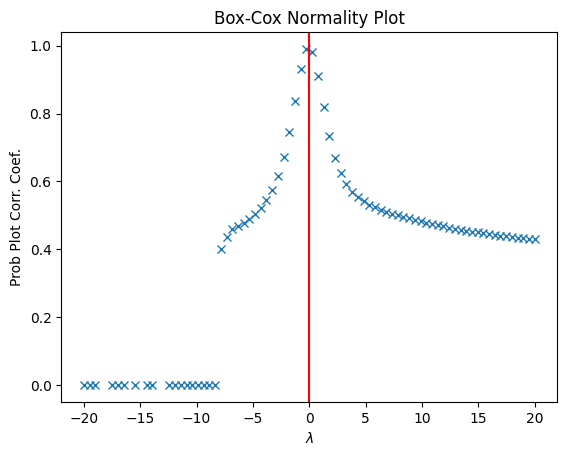

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111)
prob = boxcox_normplot(df['textile'], -20, 20, plot=ax)

ax.axvline(lmbda, color='r')
plt.show()

In [22]:
# implementa transformação box-cox com a otimização Shapiro-Wilk
# busca em grade

import numpy as np
from scipy.stats import shapiro

# transformação Box-Cox
def boxcox_transform(y, lmbda):
    y = np.asarray(y)
    if lmbda == 0:
        return np.log(y)
    return (y**lmbda - 1) / lmbda

# função objetivo (maximizar W)
def shapiro_objective(lmbda, y):
    yt = boxcox_transform(y, lmbda)
    stat, _ = shapiro(yt)
    return stat  # queremos maximizar

# busca em grade
def estimate_lambda_shapiro(y, lmbda_range=(-2, 2), n=200):
    lambdas = np.linspace(lmbda_range[0], lmbda_range[1], n)
    
    best_lambda = None
    best_stat = -np.inf
    
    for l in lambdas:
        try:
            stat = shapiro_objective(l, y)
            if stat > best_stat:
                best_stat = stat
                best_lambda = l
        except:
            continue
    
    return best_lambda, best_stat

# uso
#y = np.array([...])  # dados positivos
y = df['textile']
lambda_hat, W = estimate_lambda_shapiro(y)

print("Lambda ótimo:", lambda_hat)
print("Shapiro W:", W)

Lambda ótimo: -0.07035175879396993
Shapiro W: 0.9877349243953396
